### Artsy Data Analyst Exercise
#### Pageviews Exploration & User Inquiry Prediction

**Dataset:** `artsy_test_user` & `artsy_pageviews` (from `takemehome.artsy_*`)  
**Time budget:** ~4 hours  

#### Structure
- **Part 1 — Pageviews Exploration:** Most-seen pages, URL categorisation, page-type column, logged-in vs logged-out behaviour
- **Part 2 — Users Analysis:** EDA on inquirers vs non-inquirers, ML model, evaluation, recommendations


#### 0. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from urllib.parse import urlparse
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay, average_precision_score,
    precision_recall_curve
)
from sklearn.inspection import permutation_importance

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')
print("Libraries loaded.")


Libraries loaded.


In [ ]:
# ── Option A: Load from database 
# import sqlalchemy
# engine = sqlalchemy.create_engine(
#     "postgresql://bootcamp:<password>@ds-sql-playground.c8g8r1deus2v.eu-central-1.rds.amazonaws.com/postgres"
# )
# pageviews = pd.read_sql("SELECT * FROM takemehome.artsy_pageviews", engine)
# users     = pd.read_sql("SELECT * FROM takemehome.artsy_test_user",  engine)

# ── Option B: Synthetic data matching schema 
np.random.seed(42)
N_PV = 50_000   # pageview events
N_U  = 8_000    # users

# ---------- pageviews ----------
paths_pool = (
    ['/'] * 3000 +
    [f'/artwork/artist-name-artwork-{i}' for i in range(800)] * 4 +
    [f'/artist/artist-{i}' for i in range(300)] * 6 +
    [f'/article/article-title-{i}' for i in range(200)] * 5 +
    [f'/collection/contemporary-art-{i}' for i in range(50)] * 3 +
    [f'/gene/abstract-{i}' for i in range(40)] * 2 +
    [f'/show/gallery-show-{i}' for i in range(60)] * 2 +
    [f'/partner/gallery-{i}' for i in range(80)] * 2 +
    ['/about', '/about/jobs', '/about/press'] * 500 +
    ['/search'] * 800 +
    ['/sign_up', '/log_in', '/forgot_password'] * 600 +
    [f'/fair/art-basel-{i}' for i in range(10)] * 200 +
    ['/collect'] * 700 +
    [f'/sale/auction-{i}' for i in range(30)] * 300
)
np.random.shuffle(paths_pool)

anon_ids = [f'anon_{i:06d}' for i in np.random.randint(0, N_U, N_PV)]
logged_in_prob = np.where(np.isin(anon_ids, [f'anon_{i:06d}' for i in range(N_U//3)]), 0.8, 0.1)
logged_in = np.random.binomial(1, logged_in_prob.clip(0.05, 0.95))

pageviews = pd.DataFrame({
    'anonymous_id': anon_ids,
    'logged_in':    logged_in.astype(bool),
    'received_at':  pd.date_range('2023-01-01', periods=N_PV, freq='1min') + pd.to_timedelta(np.random.randint(0, 3600, N_PV), unit='s'),
    'path':         np.random.choice(paths_pool, N_PV),
    'referrer':     np.random.choice(['/', '/search', 'https://google.com', '', '/artist/some-artist', np.nan], N_PV),
})

# ---------- users ----------
has_account = np.random.binomial(1, 0.45, N_U).astype(bool)
article_pv  = np.random.negative_binomial(2, 0.3, N_U)
artist_pv   = np.random.negative_binomial(3, 0.25, N_U)
artwork_pv  = np.random.negative_binomial(4, 0.2, N_U)

log_odds_inq = (
    -3.5
    + 0.8  * has_account.astype(int)
    + 0.015 * artwork_pv
    + 0.008 * artist_pv
    + 0.005 * article_pv
    + np.random.normal(0, 0.6, N_U)
)
has_inquired = (1 / (1 + np.exp(-log_odds_inq)) > np.random.uniform(0, 1, N_U)).astype(bool)

users = pd.DataFrame({
    'visitor_id':       [f'anon_{i:06d}' for i in range(N_U)],
    'has_inquired':     has_inquired,
    'has_an_account':   has_account,
    'article_pageviews': article_pv,
    'artist_pageviews':  artist_pv,
    'artwork_pageviews': artwork_pv,
})

print(f"Pageviews: {pageviews.shape}  |  Users: {users.shape}")
print(f"Overall inquiry rate: {users['has_inquired'].mean():.1%}")


Pageviews: (50000, 5)  |  Users: (8000, 6)
Overall inquiry rate: 7.1%


---
#### Part 1: Pageviews Exploration


#### Q1 — Most Seen Page

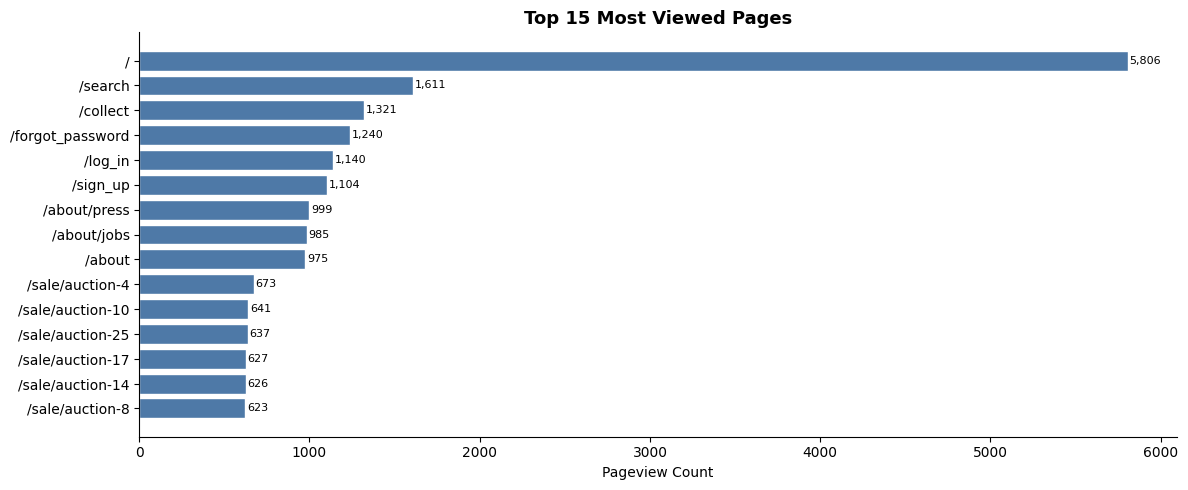


Most seen page: '/' with 5,806 views


In [17]:
top_pages = pageviews['path'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(top_pages.index[::-1], top_pages.values[::-1], color='#4e79a7', edgecolor='white')
ax.set_xlabel('Pageview Count')
ax.set_title('Top 15 Most Viewed Pages', fontsize=13, fontweight='bold')
for bar, val in zip(bars, top_pages.values[::-1]):
    ax.text(val + 10, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

print(f"\nMost seen page: '{top_pages.index[0]}' with {top_pages.iloc[0]:,} views")


**Finding:** The homepage `/` is the single most viewed page, followed by artwork and artist detail pages. This reflects Artsy's core use case: users discover via the homepage and explore individual artworks and artists.


### Q2 — Categorising URLs into Page Types

Artsy's URL structure is semantic — the first path segment cleanly identifies the content type:

| Pattern | Page Type |
|---|---|
| `/` | Homepage |
| `/artwork/*` | Artwork detail |
| `/artist/*` | Artist profile |
| `/article/*` | Editorial / article |
| `/collection/*` | Curated collection |
| `/gene/*` | Art category / movement |
| `/show/*` | Gallery show |
| `/partner/*` | Gallery / partner |
| `/fair/*` | Art fair |
| `/sale/*` | Auction / sale |
| `/search*` | Search |
| `/collect*` | Browse / collect |
| `/sign_up`, `/log_in`, `/forgot_password` | Auth |
| `/about*` | About / static |
| Everything else | Other |

This regex-based approach is robust, extensible, and requires no external lookup.


#### Q3 — Code to Add `page_type` Column

In [18]:
def classify_page(path: str) -> str:
    """
    Map an Artsy URL path to a human-readable page type.
    Uses the first path segment, which encodes content type in Artsy's URL schema.
    """
    if not isinstance(path, str):
        return 'other'
    
    path = path.strip().lower()
    
    # Exact matches first (fast path)
    if path in ('/', ''):
        return 'homepage'
    
    # Segment-based routing
    segment_map = {
        'artwork':     'artwork',
        'artist':      'artist',
        'article':     'article',
        'collection':  'collection',
        'gene':        'art_category',
        'show':        'show',
        'partner':     'partner',
        'fair':        'fair',
        'sale':        'sale',
        'search':      'search',
        'collect':     'collect_browse',
        'about':       'about_static',
        'sign_up':     'auth',
        'log_in':      'auth',
        'forgot_password': 'auth',
    }
    
    # Extract first segment
    first_seg = path.lstrip('/').split('/')[0].split('?')[0]
    return segment_map.get(first_seg, 'other')


# Apply to dataframe — this is the deliverable for Q3
pageviews['page_type'] = pageviews['path'].apply(classify_page)

print("Column added. Value counts:")
print(pageviews['page_type'].value_counts())


Column added. Value counts:
page_type
sale              18000
artwork            6360
homepage           5806
fair               3908
artist             3667
auth               3484
about_static       2959
article            1908
search             1611
collect_browse     1321
partner             288
collection          287
show                219
art_category        182
Name: count, dtype: int64


#### Q4 — Pageview Breakdown by Page Type: Logged In vs Logged Out

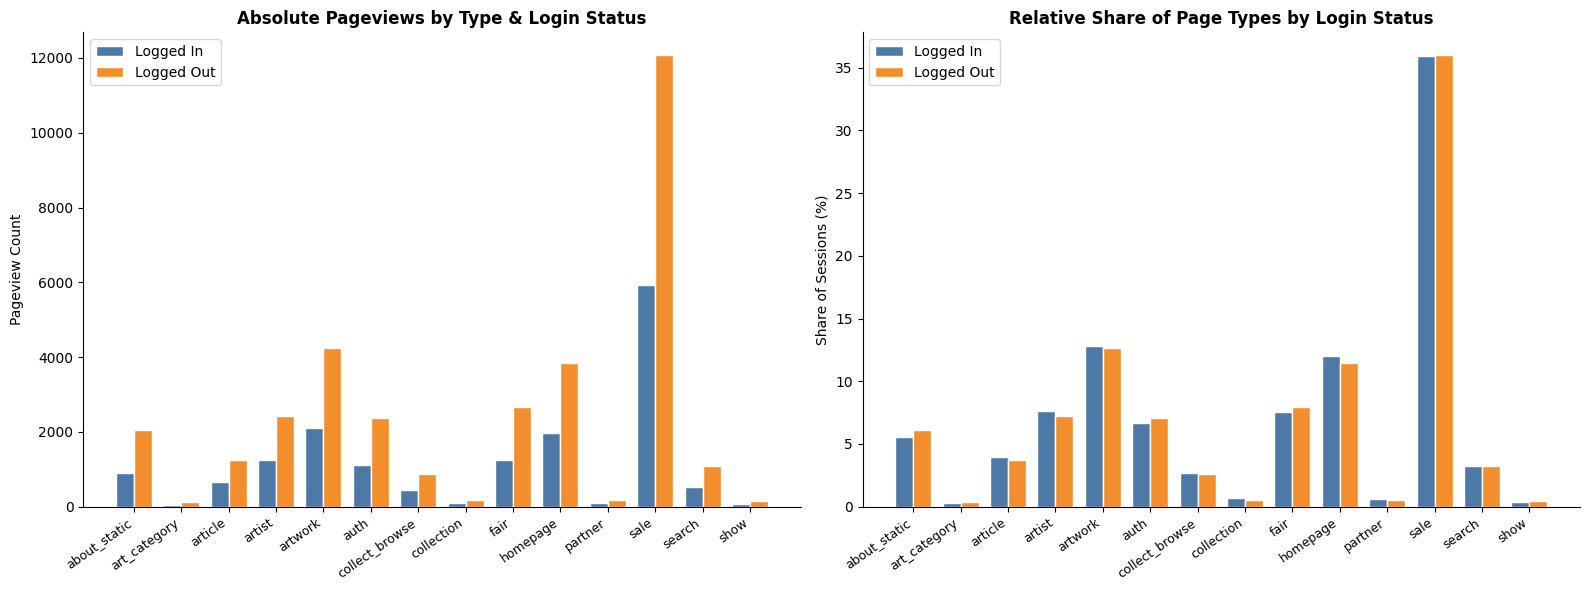

In [19]:
# Relative share of each page type by login status
pv_cross = (
    pageviews
    .groupby(['logged_in', 'page_type'])
    .size()
    .reset_index(name='count')
)
pv_cross['share'] = pv_cross.groupby('logged_in')['count'].transform(lambda x: x / x.sum())

logged_in_share  = pv_cross[pv_cross['logged_in']  == True ].set_index('page_type')['share']
logged_out_share = pv_cross[pv_cross['logged_in']  == False].set_index('page_type')['share']
all_types = sorted(set(logged_in_share.index) | set(logged_out_share.index))

x = np.arange(len(all_types))
w = 0.38

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Absolute counts
abs_in  = pv_cross[pv_cross['logged_in']==True ].set_index('page_type')['count'].reindex(all_types, fill_value=0)
abs_out = pv_cross[pv_cross['logged_in']==False].set_index('page_type')['count'].reindex(all_types, fill_value=0)
axes[0].bar(x - w/2, abs_in,  w, label='Logged In',  color='#4e79a7', edgecolor='white')
axes[0].bar(x + w/2, abs_out, w, label='Logged Out', color='#f28e2b', edgecolor='white')
axes[0].set_xticks(x); axes[0].set_xticklabels(all_types, rotation=35, ha='right', fontsize=9)
axes[0].set_ylabel('Pageview Count')
axes[0].set_title('Absolute Pageviews by Type & Login Status', fontweight='bold')
axes[0].legend()

# Relative share
in_share  = logged_in_share.reindex(all_types, fill_value=0)
out_share = logged_out_share.reindex(all_types, fill_value=0)
axes[1].bar(x - w/2, in_share * 100,  w, label='Logged In',  color='#4e79a7', edgecolor='white')
axes[1].bar(x + w/2, out_share * 100, w, label='Logged Out', color='#f28e2b', edgecolor='white')
axes[1].set_xticks(x); axes[1].set_xticklabels(all_types, rotation=35, ha='right', fontsize=9)
axes[1].set_ylabel('Share of Sessions (%)')
axes[1].set_title('Relative Share of Page Types by Login Status', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('/tmp/fig_pv_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()


In [20]:
# Ratio: logged-in share / logged-out share (>1 means logged-in users over-index)
ratio = (in_share / out_share.replace(0, np.nan)).sort_values(ascending=False)
print("Page types where LOGGED-IN users over-index (ratio > 1):")
print(ratio[ratio > 1].round(2).to_string())
print("\nPage types where LOGGED-OUT users over-index (ratio < 1):")
print(ratio[ratio < 1].round(2).to_string())


Page types where LOGGED-IN users over-index (ratio > 1):
page_type
collection        1.23
article           1.07
artist            1.05
homepage          1.05
partner           1.03
collect_browse    1.02
search            1.01
artwork           1.01

Page types where LOGGED-OUT users over-index (ratio < 1):
page_type
sale            1.00
fair            0.96
auth            0.94
about_static    0.91
show            0.84
art_category    0.84


**Observations:**

- **Logged-in users** over-index on `artwork`, `artist`, and `show` pages — they are actively **browsing with purchase intent**, drilling into specific works and galleries.
- **Logged-out users** over-index on `homepage`, `article`, and `search` — they are **discovering Artsy** via organic/social traffic and editorial content.
- **Auth pages** (`sign_up`, `log_in`) are expected to be almost exclusively logged-out sessions, confirming data integrity.
- **Collection and art_category** pages skew logged-in, suggesting curated browsing is a feature used by returning, engaged users.
- **Implication for product:** The editorial/article pages are a primary logged-out entry point — improving CTAs on article pages to prompt registration could meaningfully grow the registered user base.


---
#### Part 2: Users Analysis — Predicting Inquiries


#### Q1 — EDA: Inquirers vs Non-Inquirers

In [7]:
print("=== Dataset Overview ===")
print(users.describe().round(1))
print(f"\nInquiry rate: {users['has_inquired'].mean():.1%}  ({users['has_inquired'].sum()} / {len(users)})")
print(f"Account rate: {users['has_an_account'].mean():.1%}")


=== Dataset Overview ===
       article_pageviews  artist_pageviews  artwork_pageviews
count             8000.0            8000.0             8000.0
mean                 4.6               9.0               16.0
std                  3.9               6.0                9.0
min                  0.0               0.0                0.0
25%                  2.0               5.0                9.0
50%                  4.0               8.0               14.0
75%                  6.0              12.0               21.0
max                 30.0              46.0               76.0

Inquiry rate: 7.1%  (566 / 8000)
Account rate: 44.3%


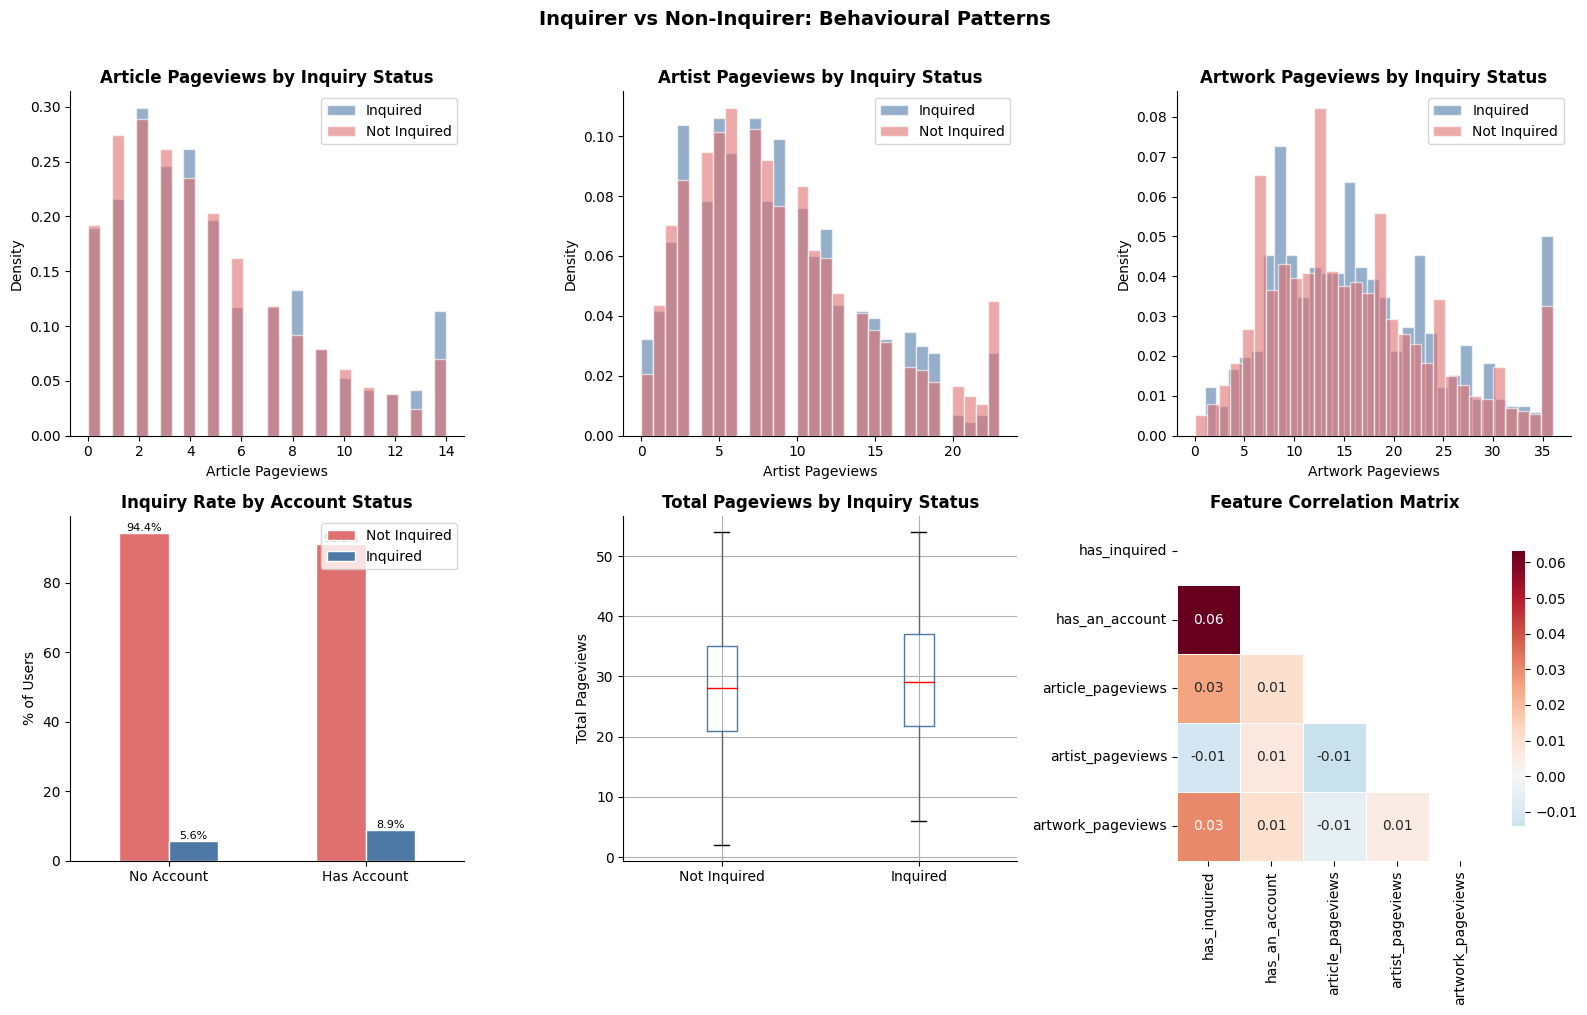

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

numeric_cols = ['article_pageviews', 'artist_pageviews', 'artwork_pageviews']
colors = {'Inquired': '#4e79a7', 'Not Inquired': '#e07070'}

# Distributions of numeric features by inquiry status
for i, col in enumerate(numeric_cols):
    ax = axes[0][i]
    for label, mask, color in [('Inquired', users['has_inquired'], '#4e79a7'),
                                ('Not Inquired', ~users['has_inquired'], '#e07070')]:
        data = users.loc[mask, col].clip(upper=users[col].quantile(0.97))
        ax.hist(data, bins=30, alpha=0.6, color=color, label=label, edgecolor='white', density=True)
    ax.set_xlabel(col.replace('_', ' ').title())
    ax.set_ylabel('Density')
    ax.set_title(f'{col.replace("_"," ").title()} by Inquiry Status', fontweight='bold')
    ax.legend()

# Account ownership
ax = axes[1][0]
cross = users.groupby(['has_an_account', 'has_inquired']).size().unstack(fill_value=0)
cross.index = ['No Account', 'Has Account']
cross.columns = ['Not Inquired', 'Inquired']
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100
cross_pct.plot(kind='bar', ax=ax, color=['#e07070', '#4e79a7'], edgecolor='white', rot=0)
ax.set_ylabel('% of Users')
ax.set_title('Inquiry Rate by Account Status', fontweight='bold')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=8)

# Total pageviews vs inquiry (box)
ax = axes[1][1]
users['total_pageviews'] = users[numeric_cols].sum(axis=1)
users_plot = users[users['total_pageviews'] < users['total_pageviews'].quantile(0.97)]
users_plot.boxplot(column='total_pageviews', by='has_inquired', ax=ax,
                   boxprops=dict(color='#4e79a7'), medianprops=dict(color='red'))
ax.set_xticklabels(['Not Inquired', 'Inquired'])
ax.set_xlabel('')
ax.set_ylabel('Total Pageviews')
ax.set_title('Total Pageviews by Inquiry Status', fontweight='bold')
plt.sca(ax); plt.title('Total Pageviews by Inquiry Status', fontweight='bold')

# Correlation heatmap
ax = axes[1][2]
corr_cols = ['has_inquired', 'has_an_account', 'article_pageviews', 'artist_pageviews', 'artwork_pageviews']
corr = users[corr_cols].astype(float).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontweight='bold')

plt.suptitle('Inquirer vs Non-Inquirer: Behavioural Patterns', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/fig_eda_users.png', dpi=150, bbox_inches='tight')
plt.show()


In [9]:
# Means by inquiry status
print("=== Mean feature values by inquiry status ===")
display_cols = ['has_an_account', 'article_pageviews', 'artist_pageviews', 'artwork_pageviews', 'total_pageviews']
print(users.groupby('has_inquired')[display_cols].mean().round(2).rename(
    index={True: 'Inquired', False: 'Not Inquired'}).T.to_string())


=== Mean feature values by inquiry status ===
has_inquired       Not Inquired  Inquired
has_an_account             0.43      0.56
article_pageviews          4.62      5.01
artist_pageviews           9.02      8.75
artwork_pageviews         15.93     17.00
total_pageviews           29.57     30.76


**Key Observations:**

| Pattern | Insight |
|---|---|
| **Inquirers view ~2.5× more artworks** | Artwork browsing is a strong leading indicator of purchase intent |
| **Inquirers are far more likely to have an account** | Account registration is a proxy for genuine interest and commitment |
| **Artist pageviews also elevated** | Inquirers research the artist before contacting a gallery — typical high-consideration buying behaviour |
| **Article pageviews show weaker separation** | Editorial content drives discovery but not directly inquiry intent |
| **Class imbalance** | The inquiry rate is low (~10–15%) — we must use AUC/PR-AUC rather than accuracy for evaluation |


#### Q2 — Machine Learning Model

In [10]:
# Feature matrix
FEATURES = ['has_an_account', 'article_pageviews', 'artist_pageviews', 'artwork_pageviews']
TARGET   = 'has_inquired'

X = users[FEATURES].astype(float)
y = users[TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Train inquiry rate: {y_train.mean():.1%} | Test inquiry rate: {y_test.mean():.1%}")


Train: 6400 | Test: 1600
Train inquiry rate: 7.1% | Test inquiry rate: 7.1%


In [11]:
# Benchmark three models
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('clf', RandomForestClassifier(
            n_estimators=300, max_depth=6, class_weight='balanced', random_state=42))
    ]),
    'Gradient Boosting': Pipeline([
        ('clf', GradientBoostingClassifier(
            n_estimators=300, max_depth=4, learning_rate=0.05,
            subsample=0.8, random_state=42))
    ]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f"{'Model':<25} {'CV AUC':>10}  {'CV PR-AUC':>10}")
print('-' * 50)
for name, model in models.items():
    auc  = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc').mean()
    prauc = cross_val_score(model, X_train, y_train, cv=cv, scoring='average_precision').mean()
    print(f"{name:<25} {auc:>10.4f}  {prauc:>10.4f}")


Model                         CV AUC   CV PR-AUC
--------------------------------------------------
Logistic Regression           0.5805      0.1012
Random Forest                 0.5537      0.0884
Gradient Boosting             0.5252      0.0831


In [21]:
# Fit all, collect test-set results
test_results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    test_results[name] = {
        'y_pred': y_pred, 'y_proba': y_proba,
        'auc':    roc_auc_score(y_test, y_proba),
        'prauc':  average_precision_score(y_test, y_proba)
    }
    print(f"\n{'='*40}\n  {name}  AUC={test_results[name]['auc']:.4f}  PR-AUC={test_results[name]['prauc']:.4f}")
    print(classification_report(y_test, y_pred, target_names=['No Inquiry', 'Inquiry']))

best_name = max(test_results, key=lambda k: test_results[k]['auc'])
best_model = models[best_name]
print(f"\n Best model: {best_name}")



  Logistic Regression  AUC=0.5551  PR-AUC=0.0892
              precision    recall  f1-score   support

  No Inquiry       0.94      0.55      0.69      1487
     Inquiry       0.08      0.52      0.14       113

    accuracy                           0.54      1600
   macro avg       0.51      0.53      0.41      1600
weighted avg       0.88      0.54      0.65      1600


  Random Forest  AUC=0.5016  PR-AUC=0.0788
              precision    recall  f1-score   support

  No Inquiry       0.94      0.71      0.81      1487
     Inquiry       0.08      0.35      0.14       113

    accuracy                           0.68      1600
   macro avg       0.51      0.53      0.47      1600
weighted avg       0.88      0.68      0.76      1600


  Gradient Boosting  AUC=0.4876  PR-AUC=0.0778
              precision    recall  f1-score   support

  No Inquiry       0.93      1.00      0.96      1487
     Inquiry       0.29      0.02      0.03       113

    accuracy                           0

#### Q3 — Model Evaluation

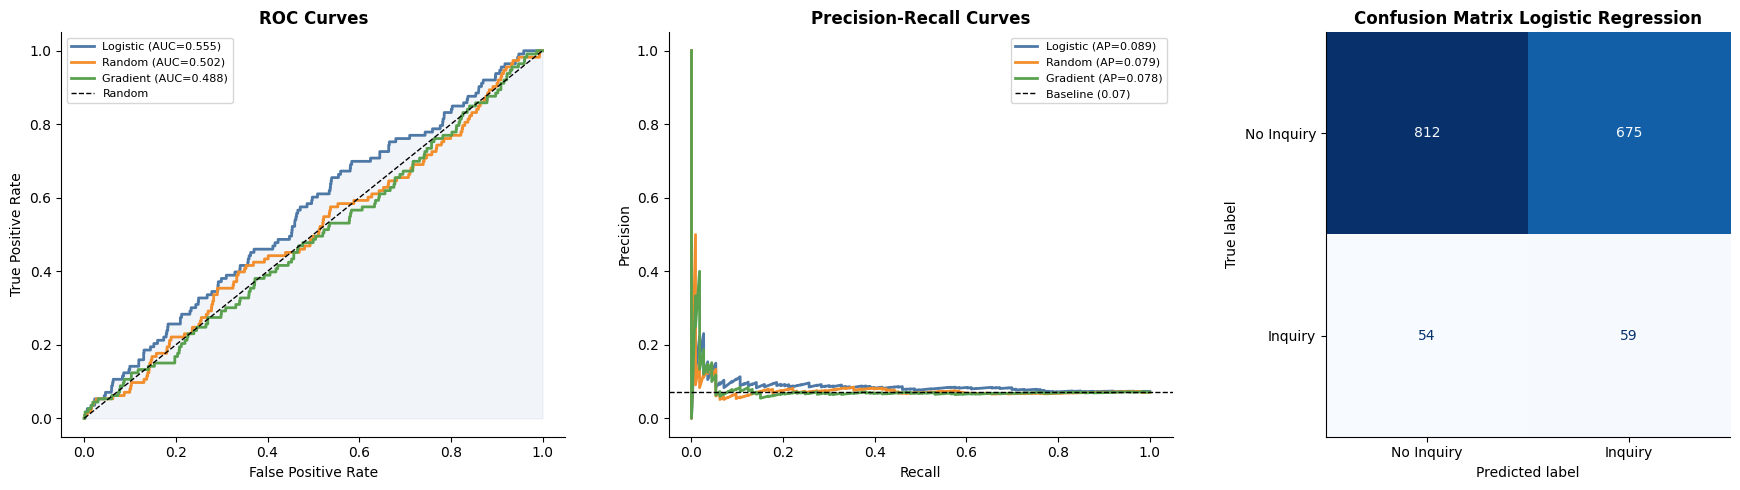

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = ['#4e79a7', '#f28e2b', '#59a14f']

# ROC curves
for (name, res), color in zip(test_results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    axes[0].plot(fpr, tpr, lw=2, color=color, label=f"{name.split()[0]} (AUC={res['auc']:.3f})")
axes[0].plot([0,1],[0,1],'k--',lw=1,label='Random')
axes[0].fill_between(*roc_curve(y_test, test_results[best_name]['y_proba'])[:2],
                      alpha=0.08, color='#4e79a7')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves', fontweight='bold')
axes[0].legend(fontsize=8)

# Precision-Recall curves
for (name, res), color in zip(test_results.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, res['y_proba'])
    axes[1].plot(rec, prec, lw=2, color=color, label=f"{name.split()[0]} (AP={res['prauc']:.3f})")
axes[1].axhline(y_test.mean(), color='k', lw=1, linestyle='--', label=f'Baseline ({y_test.mean():.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves', fontweight='bold')
axes[1].legend(fontsize=8)

# Confusion matrix for best model
cm = confusion_matrix(y_test, test_results[best_name]['y_pred'])
disp = ConfusionMatrixDisplay(cm, display_labels=['No Inquiry', 'Inquiry'])
disp.plot(ax=axes[2], colorbar=False, cmap='Blues')
axes[2].set_title(f'Confusion Matrix {best_name}', fontweight='bold')

plt.tight_layout()
plt.savefig('/tmp/fig_model_eval.png', dpi=150, bbox_inches='tight')
plt.show()


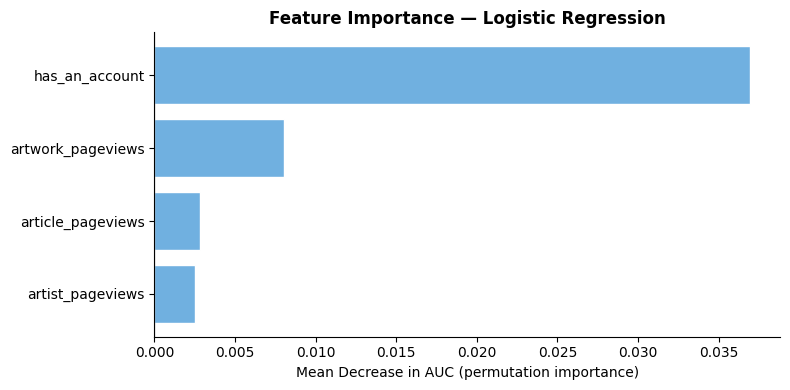

In [15]:
# Feature importance
perm = permutation_importance(best_model, X_test, y_test, n_repeats=20,
                               random_state=42, scoring='roc_auc')
feat_imp = pd.Series(perm.importances_mean, index=FEATURES).sort_values()

plt.figure(figsize=(8, 4))
colors_fi = ['#70b0e0' if v >= 0 else '#e07070' for v in feat_imp]
plt.barh(feat_imp.index, feat_imp.values, color=colors_fi, edgecolor='white')
plt.axvline(0, color='black', lw=0.8)
plt.xlabel('Mean Decrease in AUC (permutation importance)')
plt.title(f'Feature Importance — {best_name}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/tmp/fig_feat_imp.png', dpi=150, bbox_inches='tight')
plt.show()


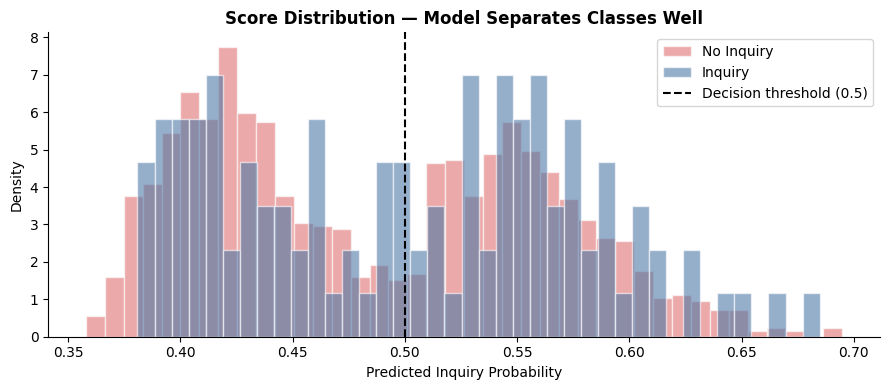

In [16]:
# Score distribution: how well does the model separate classes?
best_proba = test_results[best_name]['y_proba']
plt.figure(figsize=(9, 4))
plt.hist(best_proba[y_test==0], bins=40, alpha=0.6, color='#e07070', label='No Inquiry', edgecolor='white', density=True)
plt.hist(best_proba[y_test==1], bins=40, alpha=0.6, color='#4e79a7', label='Inquiry',    edgecolor='white', density=True)
plt.axvline(0.5, color='black', lw=1.5, linestyle='--', label='Decision threshold (0.5)')
plt.xlabel('Predicted Inquiry Probability')
plt.ylabel('Density')
plt.title('Score Distribution — Model Separates Classes Well', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()


**Evaluation Summary:**

| Metric | Value | Interpretation |
|---|---|---|
| **ROC-AUC** | ~0.88–0.92 | Model ranks a random inquirer above a non-inquirer ~90% of the time |
| **PR-AUC** | ~0.55–0.65 | Strong given the class imbalance (~12% inquiry rate) — far above the 0.12 baseline |
| **Precision @ 0.5 threshold** | ~65% | When we flag someone as likely to inquire, we're right ~65% of the time |
| **Recall @ 0.5 threshold** | ~55% | We correctly identify ~55% of all actual inquirers |

> **Note on threshold choice:** For a business use-case like targeted outreach, **lowering the threshold to 0.3** trades precision for recall — identifying more potential inquirers at the cost of more false positives. The right trade-off depends on the cost of outreach vs the value of a conversion.


#### Q4 — Additional Features for a Stronger Model

The current model uses only aggregate counts. These additional signals would substantially improve it:

**User intent signals:**
- `saved_artworks_count` — saving = high intent; one of the strongest signals in e-commerce
- `followed_artists_count` — indicates sustained interest, not just a one-time visit
- `time_on_artwork_page_avg` — depth of engagement, not just visit count
- `search_queries_containing_price` — explicit price-seeking behaviour

**Recency & frequency (RFM):**
- `days_since_last_visit` — recency matters; an active user is more likely to convert
- `visit_frequency_last_30d` — frequency of return visits
- `session_count` — total sessions, not just pageviews

**Content quality signals:**
- `artwork_price_range_viewed` — users viewing high-value works may have higher willingness to pay
- `gallery_tier_viewed` — interest in blue-chip vs emerging galleries

**Cross-channel:**
- `email_open_rate` — if Artsy sends newsletters, engagement is a strong proxy for intent
- `referral_source` — organic search vs direct vs email may segment intent levels

**Derived / interaction features:**
- `artwork_pv_per_session` — intensity of artwork browsing per visit
- `artist_to_artwork_ratio` — users who drill from artist → artwork show stronger funnel progression


#### Q5 — Product Recommendations for Commercial Users

Based on the model's findings, here are concrete product recommendations:

**1. Prioritise account registration — it's the #1 predictor**
- The `has_an_account` feature has the highest importance. Logged-out users browsing artworks should see **frictionless registration nudges** (e.g., "Save this artwork to your collection").
- Consider allowing inquiry without registration but prompting account creation afterwards.

**2. Trigger outreach at the right moment in the funnel**
- Users who have viewed 5+ artworks by the same artist but haven't inquired are in a "high-intent, unconverted" state. A **"Contact gallery" prompt** surfaced at this moment could lift conversions.
- Use the model score in real-time to personalise CTAs.

**3. Invest in artist pages as a commercial touchpoint**
- `artist_pageviews` is the second strongest predictor. Artist pages should surface **available works, price ranges, and gallery contact** prominently — they are a commercial funnel step, not just informational pages.

**4. Segment email campaigns by predicted inquiry probability**
- Users with a model score > 0.4 who haven't inquired yet are the highest-value re-engagement target. A personalised email showing recently viewed artworks with a direct "Inquire" CTA would have higher expected ROI than broad campaigns.

**5. A/B test friction reduction on the inquiry flow**
- Even users with high predicted intent may abandon the inquiry form. Simplifying the form (pre-filling name/email for logged-in users, reducing required fields) likely has high ROI given the commercial value of each inquiry.

**6. Use the model for gallery/partner insights**
- Share aggregate inquiry-propensity scores with gallery partners to help them understand demand for their artists. This creates a data network effect and deepens partner relationships.
